In [115]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import portfolio_analytics as erk

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [116]:
ind = erk.get_ind_returns()
er = erk.annualize_rets(ind['1996':'2000'],12)
cov = ind['1996':'2000'].cov()

In [117]:
''' '''
def plot_ef(n_points, er, cov):
    """ Plots the n-asset efficient frontier"""
    weights = minimize_vol(target_return)
    rets = [erk.portfolio_return(w, er) for w in weights]
    vols = [erk.portfolio_vol(w, er ) for w in weights]
    ef = pd.DataFrame({
        "Returns": rets,
        "volatility": vols
    })
    return ef.plot.line(x="volatility", y="Returns")

In [118]:
from scipy.optimize import minimize

<Axes: xlabel='Volatility'>

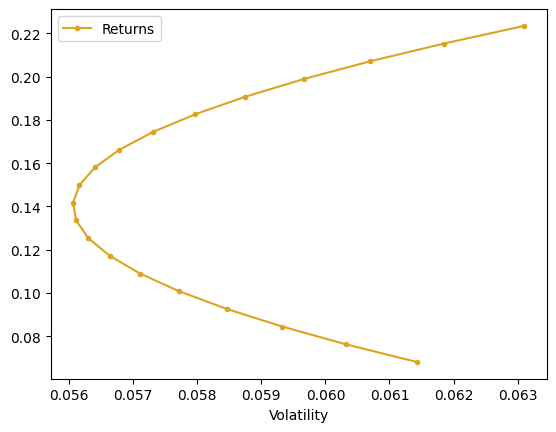

In [119]:
l = ["Games","Fin"]
erk.plot_ef2(20, er[l], cov.loc[l,l])

In [120]:
def target_is_met(w, er, target_return):
    return target_return - erk.portfolio_return(w,er)
def minimize_vol(target_return, er, cov):
    """
    Returns the optimal weights that achieve the target return
    given a set of expected returns and a covariance matrix
    """
    n = er.shape[0]
    init_guess = np.repeat(1/n, n)
    bounds = ((0.0, 1.0),) * n # an N-tuple of 2-tuples!
    # construct the constraints
    weights_sum_to_1 = {'type': 'eq',
                        'fun': lambda weights: np.sum(weights) - 1
    }
    return_is_target = {'type': 'eq',
                        'args': (er,),
                        'fun': lambda weights, er: target_return - erk.portfolio_return(weights,er)
    }
    weights = minimize(erk.portfolio_vol, init_guess,
                       args=(cov,), method='SLSQP',
                       options={'disp': False},
                       constraints=(weights_sum_to_1,return_is_target),
                       bounds=bounds)
    return weights.x


In [121]:
l

['Games', 'Fin']

In [122]:
w15 = minimize_vol(0.15, er[l], cov.loc[l,l])
vol15 = erk.portfolio_vol(w15, cov.loc[l,l])
vol15

np.float64(0.05616366940670658)

In [123]:
w15

array([0.47287631, 0.52712369])

<Axes: title={'center': 'Efficient Frontier'}, xlabel='Annualized Volatility', ylabel='Annualized Return'>

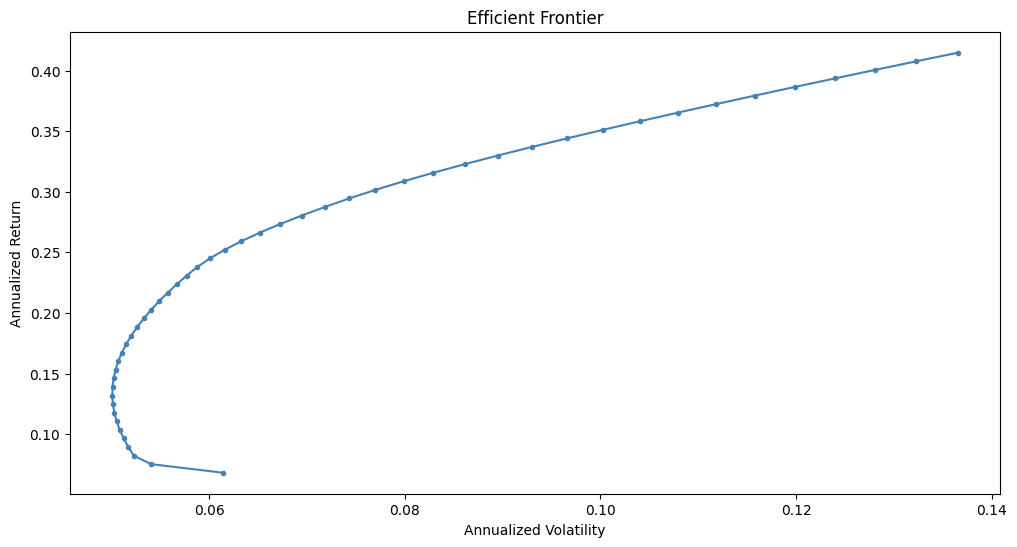

In [130]:
l = ["Smoke", "Fin","Games" ,"Coal"]
erk.plot_ef(50, er[l], cov.loc[l,l])